# This is the tutuorial for Geo2Vec
including visualization of the learning process and experinmental evaluation. 
You can just using this notebook to generate the embedding in a explicit way.

In [1]:
import numpy as np
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"
import multiprocessing
import gc
import argparse
import torch
import random
import time
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
# from sys import path
# path.append('..')
#import utils.test_representation as test_representation
from utils import test_representation
from utils.visualization import plot_polygon
#from models.Geo2Vec import Geo2Vec_Model, Geo2Vec_Dataset, SDFLoss
from models.Geo2Vec import Geo2Vec_Model, Geo2Vec_Dataset, SDFLoss
from models import MP_Sampling
#from models import MP_Sampling
#from utils.data_loader import load_data,preprocessing_list
from utils.data_loader import load_data,preprocessing_list
import utils.visualization as visualization
import matplotlib.pyplot as plt

/home/users/chen/anaconda3/envs/torchcc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Set your parameters

In [2]:
def get_args():
    parser = argparse.ArgumentParser(description="Geo2vec Training Config")

    # file_path: where the data is stored in pkl or gpkg format
    file_path = r'data\ShapeClassification.gpkg'
    parser.add_argument('--file_path', type=str, default=file_path)
    # Save file path
    save_path = os.path.splitext(file_path)[0] + '.pth'
    parser.add_argument('--save_file_name', type=str, default=save_path)

    cpu_count = os.cpu_count()
    print(f"Number of CPUs: {cpu_count}")
    cpu_count = max(1, cpu_count-4)  # leave some cpu for other tasks

    # Sampling Parameters
    # For location
    parser.add_argument('--num_process', type=int, default=cpu_count)
    parser.add_argument('--samples_perUnit_location', type=int, default=4000)
    parser.add_argument('--point_sample_location', type=int, default=10)
    parser.add_argument('--sample_band_width_location', type=float, default=0.2)
    parser.add_argument('--uniformed_sample_perUnit_location', type=int, default=30)

    # For shape
    parser.add_argument('--samples_perUnit_shape', type=int, default=300)
    parser.add_argument('--point_sample_shape', type=int, default=20)
    parser.add_argument('--sample_band_width_shape', type=float, default=0.1)
    parser.add_argument('--uniformed_sample_perUnit_shape', type=int, default=40)

    # Training parameters
    # For location
    parser.add_argument('--batch_size', type=int, default=1024 * 20)
    parser.add_argument('--num_workers', type=int, default=8)  # Training dataload number of works

    parser.add_argument('--epochs_location', type=int, default=5)
    parser.add_argument('--num_layers_location', type=int, default=8)
    parser.add_argument('--z_size_location', type=int, default=256)
    parser.add_argument('--hidden_size_location', type=int, default=256)
    parser.add_argument('--num_freqs_location', type=int, default=16)
    parser.add_argument('--device', type=str, default='cuda' if torch.cuda.is_available() else 'cpu')
    parser.add_argument('--code_reg_weight_location', type=float, default=0.0)
    parser.add_argument('--weight_decay_location', type=float, default=0.01)
    parser.add_argument('--polar_fourier_location', action='store_true', default=False)
    parser.add_argument('--log_sampling_location', action='store_true', default=False)
    parser.add_argument('--training_ratio_location', type=float, default=0.95)

    # For shape
    parser.add_argument('--epochs_shape', type=int, default=5)
    parser.add_argument('--num_layers_shape', type=int, default=8)
    parser.add_argument('--z_size_shape', type=int, default=256)
    parser.add_argument('--hidden_size_shape', type=int, default=256)
    parser.add_argument('--num_freqs_shape', type=int, default=8)
    parser.add_argument('--device_shape', type=str, default='cuda' if torch.cuda.is_available() else 'cpu')
    parser.add_argument('--code_reg_weight_shape', type=float, default=1.0)
    parser.add_argument('--weight_decay_shape', type=float, default=0.01)
    parser.add_argument('--polar_fourier_shape', action='store_true', default=False)
    parser.add_argument('--log_sampling_shape', action='store_true', default=True)
    parser.add_argument('--training_ratio_shape', type=float, default=0.95)

    # Testing options
    # For location
    parser.add_argument('--test_representation_location', type=bool, default=True)
    parser.add_argument('--visualSDF_location', type=bool, default=True)
    # For shape
    parser.add_argument('--test_representation_shape', type=bool, default=True)
    parser.add_argument('--visualSDF_shape', type=bool, default=True)
    return parser.parse_args()

args = get_args()
device = torch.device(args.device)

Number of CPUs: 24


# Load your data here
Notice the data will be normalized, we support .pkl, .gpkg, .shp, .json, .geojson for now.

In [3]:
file_path = 'data/ShapeClassification.gpkg'
polys_dict_shape,polys_dict_loc, classification_labels, areas_labels, perimeters_labels, num_edges_labels = load_data(file_path)

Loading ...  data/ShapeClassification.gpkg


5010it [00:00, 5850.85it/s]


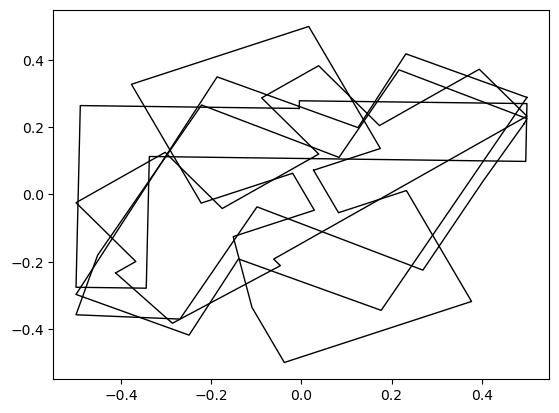

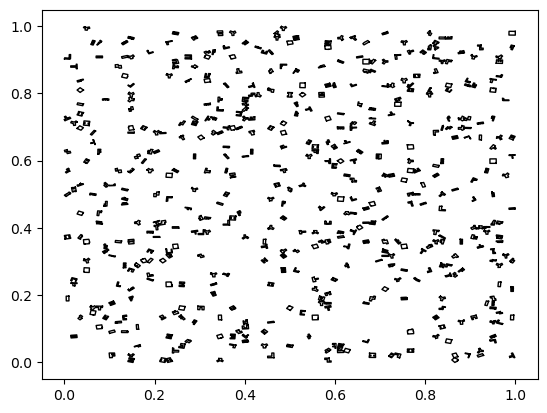

In [4]:
# Randomly visualize some shapes
sample_keys = random.sample(list(polys_dict_shape.keys()), 5)
for key in sample_keys:
    polygon = polys_dict_shape[key]
    plot_polygon(polygon)
plt.show()
sample_keys = random.sample(list(polys_dict_loc.keys()), len(polys_dict_loc)//10)
for key in sample_keys:
    polygon = polys_dict_loc[key]
    plot_polygon(polygon)
plt.show()

# Let's learn shape representation first.
# Sampling using multiprocess & Visualizing the sampled points.
Notice: We sample and learn shape representation first and then learn location representation. 

In [27]:
multiprocessing.set_start_method("spawn", force=True)
samples = MP_Sampling.MP_sample(polys_dict_shape, args.num_process, samples_perUnit=args.samples_perUnit_shape, point_sample=args.point_sample_shape,
                                sample_band_width=args.sample_band_width_shape,uniformed_sample_perUnit=args.uniformed_sample_perUnit_shape, buffer=0.3)
#We set buffer to 0.3 to ensure a better visualization in this tutorial, in practice, it does not affect the results with smaller buffer.

Bounding box: (-0.800000000000004, 0.800000000000004, -0.800000000000004, 0.800000000000004)


100%|██████████| 5010/5010 [00:37<00:00, 132.47it/s]


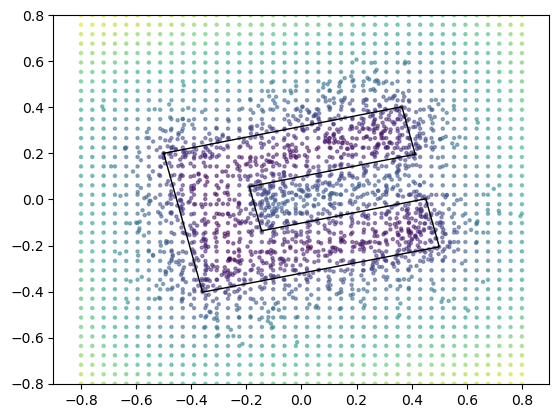

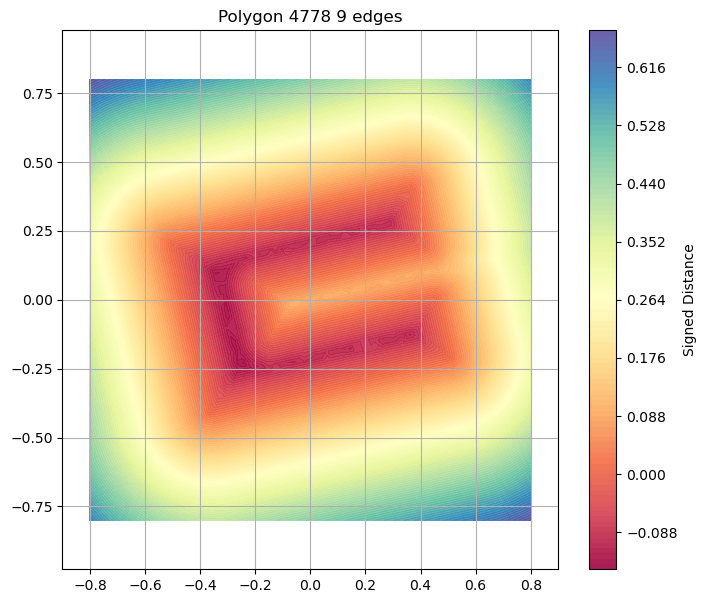

In [28]:
id = random.choice(list(samples.keys()))
poly = polys_dict_shape[id]
samples_pt, distance = samples[id]
plot_polygon(poly)

xs = [x[0] for x in poly.exterior.coords]
ys = [x[1] for x in poly.exterior.coords]
delta= 0.4
bounds = ((min(xs)-delta, max(xs)+delta), (min(ys)-delta, max(ys)+delta))
plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])

xs_pt = [x[0] for x in samples_pt]
ys_pt = [x[1] for x in samples_pt]
plt.scatter(xs_pt, ys_pt, c=distance, cmap='viridis', marker='o', s=5, alpha=0.5)
plt.show()


# contour base on xs,ys,distance
plt.figure(figsize=(8, 7))
contour = plt.tricontourf(xs_pt, ys_pt, distance, levels=100, cmap='Spectral', alpha=0.9)
plt.colorbar(contour, label='Signed Distance')
plt.title(f'Polygon {id} ' +str(len(poly.exterior.coords)) + ' edges')
plt.axis('equal')
plt.grid(True)
plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
plt.show()

# Training a Geo2Vec model to learn shape representation
Notice that we oversample points in this tutorial for better visualization, in practice, it does not affect the results with smaller number of sampling points.

In [29]:
z_size = args.z_size_shape
hidden_size = args.hidden_size_shape
num_freqs = args.num_freqs_shape
code_reg_weight = args.code_reg_weight_shape
weight_decay = args.weight_decay_shape
num_layers = args.num_layers_shape
epochs = args.epochs_shape
polar_fourier = args.polar_fourier_shape
log_sampling = args.log_sampling_shape

training_ratio = args.training_ratio_shape
samples_perUnit = args.samples_perUnit_shape
point_sample = args.point_sample_shape
sample_band_width = args.sample_band_width_shape
uniformed_sample_perUnit = args.uniformed_sample_perUnit_shape
batch_size = args.batch_size
num_workers = args.num_workers

In [ ]:
max_id = max(polys_dict_shape.keys())
total_dataset = Geo2Vec_Dataset(samples, polys_dict_shape.keys())
samples = None # Free up memory
gc.collect()

train_size = round(training_ratio * len(total_dataset))
val_size = len(total_dataset) - train_size
train_dataset, val_dataset = random_split(total_dataset, [train_size, val_size])
total_dataset = None # Free up memory
gc.collect()
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False,
                        num_workers=num_workers,
                        pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False,
                            num_workers=num_workers,
                            pin_memory=True)

print(f"In average training samples per entity: {len(train_dataset) / len(polys_dict_shape)}")

In average training samples per entity: 2709.7127744510976


0.010006273165345192


100%|██████████| 663/663 [00:46<00:00, 14.41it/s]


{'H', 'T', 'Y', 'F', 'O', 'I', 'Z', 'E', 'L', 'U'}
Epoch [1/100], Loss: 2.2278, Accuracy:22.04%   29.69%  31.78%
Epoch [11/100], Loss: 0.4271, Accuracy:85.20%   90.55%  89.10%
Epoch [21/100], Loss: 0.2551, Accuracy:91.53%   92.54%  91.36%
Epoch [31/100], Loss: 0.1789, Accuracy:94.35%   94.01%  94.68%
Epoch [41/100], Loss: 0.1298, Accuracy:96.07%   94.94%  94.68%
Epoch [51/100], Loss: 0.1021, Accuracy:96.72%   94.27%  94.68%
Epoch [61/100], Loss: 0.0774, Accuracy:97.43%   95.07%  95.61%
Epoch [71/100], Loss: 0.0631, Accuracy:98.18%   95.61%  95.61%
Epoch [81/100], Loss: 0.0607, Accuracy:98.09%   95.87%  95.35%
Epoch [91/100], Loss: 0.0480, Accuracy:98.52%   95.34%  95.48%
initiation_accuracy_train: 22.04%, accuracy_test: 29.69%, accuracy_val: 31.78%
afterwards_accuracy_train: 98.83%, accuracy_test: 95.34%, accuracy_val: 95.35%


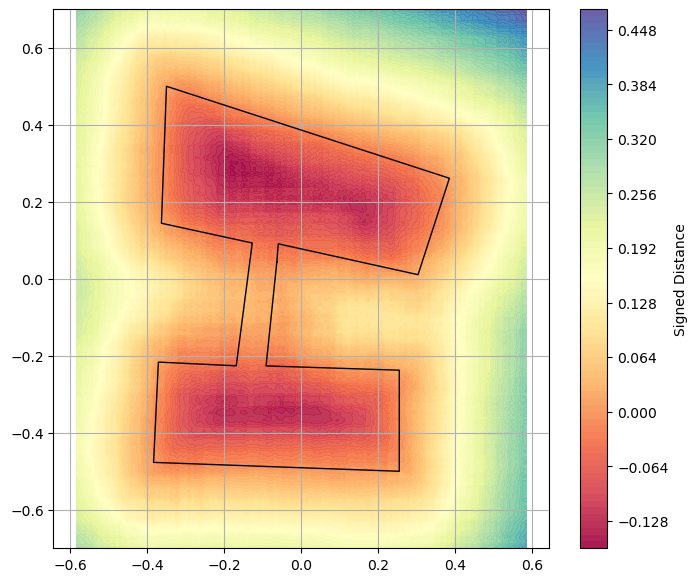

Epoch 1/5, Loss: 571.6082410855531, TEST Loss: 0.34191969968378544
0.0314594991505146


100%|██████████| 663/663 [00:45<00:00, 14.55it/s]


{'H', 'T', 'Y', 'F', 'O', 'I', 'Z', 'E', 'L', 'U'}
Epoch [1/100], Loss: 2.2135, Accuracy:22.70%   44.07%  40.03%
Epoch [11/100], Loss: 0.3335, Accuracy:88.96%   91.61%  91.62%
Epoch [21/100], Loss: 0.1779, Accuracy:94.44%   94.41%  93.35%
Epoch [31/100], Loss: 0.1093, Accuracy:96.58%   94.81%  94.02%
Epoch [41/100], Loss: 0.0871, Accuracy:97.41%   95.61%  94.41%
Epoch [51/100], Loss: 0.0586, Accuracy:97.89%   95.87%  94.68%
Epoch [61/100], Loss: 0.0535, Accuracy:98.57%   96.40%  94.95%
Epoch [71/100], Loss: 0.0441, Accuracy:98.60%   96.01%  95.35%
Epoch [81/100], Loss: 0.0277, Accuracy:99.20%   95.87%  95.08%
Epoch [91/100], Loss: 0.0285, Accuracy:99.17%   96.67%  95.21%
initiation_accuracy_train: 22.70%, accuracy_test: 44.07%, accuracy_val: 40.03%
afterwards_accuracy_train: 99.03%, accuracy_test: 96.54%, accuracy_val: 95.48%


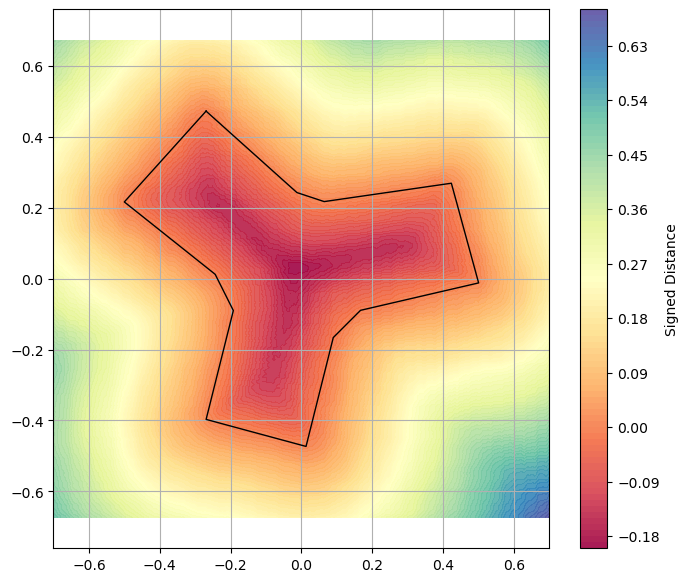

Epoch 2/5, Loss: 156.5809832151479, TEST Loss: 0.20694140391424298
0.037678126245737076


100%|██████████| 663/663 [00:45<00:00, 14.43it/s]


{'H', 'T', 'Y', 'F', 'O', 'I', 'Z', 'E', 'L', 'U'}
Epoch [1/100], Loss: 2.1917, Accuracy:27.74%   48.07%  44.55%
Epoch [11/100], Loss: 0.3102, Accuracy:89.08%   90.28%  92.15%
Epoch [21/100], Loss: 0.1725, Accuracy:94.18%   92.94%  94.41%
Epoch [31/100], Loss: 0.1205, Accuracy:96.21%   95.07%  94.68%
Epoch [41/100], Loss: 0.0760, Accuracy:97.55%   95.21%  95.74%
Epoch [51/100], Loss: 0.0508, Accuracy:98.60%   95.47%  96.41%
Epoch [61/100], Loss: 0.0458, Accuracy:98.43%   96.01%  96.54%
Epoch [71/100], Loss: 0.0320, Accuracy:98.97%   95.74%  96.14%
Epoch [81/100], Loss: 0.0315, Accuracy:98.94%   96.14%  97.07%
Epoch [91/100], Loss: 0.0243, Accuracy:99.26%   96.27%  96.68%
initiation_accuracy_train: 27.74%, accuracy_test: 48.07%, accuracy_val: 44.55%
afterwards_accuracy_train: 99.23%, accuracy_test: 96.40%, accuracy_val: 96.68%


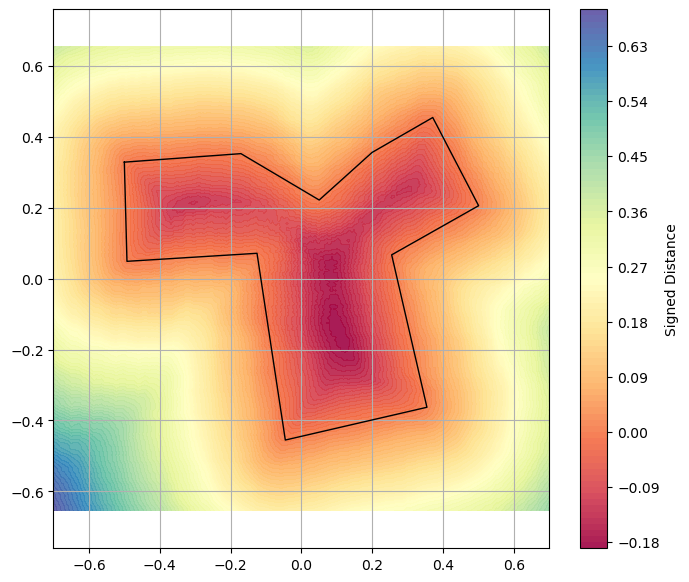

Epoch 3/5, Loss: 116.63197768543641, TEST Loss: 0.16649121837690473
0.042320381850004196


100%|██████████| 663/663 [00:45<00:00, 14.56it/s]


{'H', 'T', 'Y', 'F', 'O', 'I', 'Z', 'E', 'L', 'U'}
Epoch [1/100], Loss: 2.1847, Accuracy:24.44%   45.41%  46.28%
Epoch [11/100], Loss: 0.2750, Accuracy:90.96%   92.94%  91.22%
Epoch [21/100], Loss: 0.1567, Accuracy:94.61%   95.07%  93.62%
Epoch [31/100], Loss: 0.1049, Accuracy:96.64%   95.47%  95.21%
Epoch [41/100], Loss: 0.0580, Accuracy:98.52%   96.54%  95.74%
Epoch [51/100], Loss: 0.0475, Accuracy:98.52%   96.94%  96.68%
Epoch [61/100], Loss: 0.0423, Accuracy:98.72%   97.20%  96.41%
Epoch [71/100], Loss: 0.0329, Accuracy:98.83%   97.07%  96.68%
Epoch [81/100], Loss: 0.0279, Accuracy:99.20%   96.80%  96.41%
Epoch [91/100], Loss: 0.0191, Accuracy:99.40%   97.87%  96.41%
initiation_accuracy_train: 24.44%, accuracy_test: 45.41%, accuracy_val: 46.28%
afterwards_accuracy_train: 99.32%, accuracy_test: 97.60%, accuracy_val: 97.34%


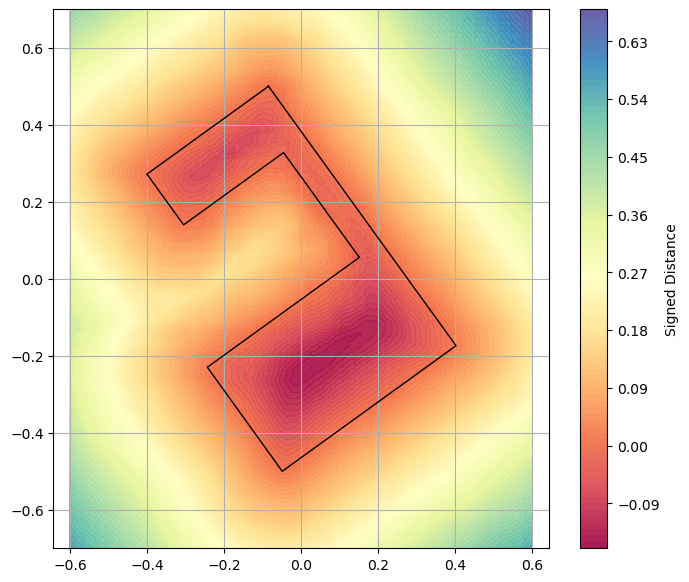

Epoch 4/5, Loss: 101.19997798407599, TEST Loss: 0.1592343063093722
0.04634242132306099


100%|██████████| 663/663 [00:46<00:00, 14.19it/s]


{'H', 'T', 'Y', 'F', 'O', 'I', 'Z', 'E', 'L', 'U'}
Epoch [1/100], Loss: 2.1884, Accuracy:24.69%   42.61%  40.03%
Epoch [11/100], Loss: 0.2841, Accuracy:90.70%   92.94%  91.49%
Epoch [21/100], Loss: 0.1453, Accuracy:95.18%   94.67%  94.81%
Epoch [31/100], Loss: 0.0904, Accuracy:97.21%   95.74%  96.41%
Epoch [41/100], Loss: 0.0583, Accuracy:98.32%   95.87%  96.54%
Epoch [51/100], Loss: 0.0559, Accuracy:98.12%   95.61%  96.28%
Epoch [61/100], Loss: 0.0365, Accuracy:98.89%   96.40%  96.54%
Epoch [71/100], Loss: 0.0310, Accuracy:99.03%   96.54%  96.94%
Epoch [81/100], Loss: 0.0227, Accuracy:99.32%   96.94%  97.21%
Epoch [91/100], Loss: 0.0198, Accuracy:99.43%   96.80%  96.54%
initiation_accuracy_train: 24.69%, accuracy_test: 42.61%, accuracy_val: 40.03%
afterwards_accuracy_train: 99.54%, accuracy_test: 96.40%, accuracy_val: 97.21%


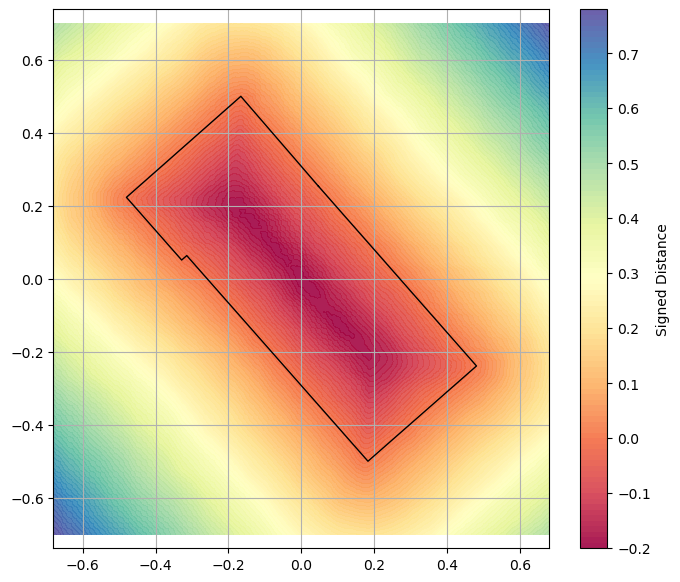

Epoch 5/5, Loss: 90.66136220066076, TEST Loss: 0.14584930334240198


In [58]:
model = Geo2Vec_Model(n_poly=max_id + 2, z_size=z_size, hidden_size=hidden_size, num_freqs=num_freqs,
                        weight_decay=weight_decay, log_sampling=log_sampling,
                        polar_fourier=polar_fourier, num_layers=num_layers).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = SDFLoss(code_reg_weight=code_reg_weight, sum=True)
id_range = torch.arange(0, max_id + 2, dtype=torch.long).to(device)
best_val_loss = float('inf')
for epoch in range(epochs):
    print(torch.std(model.poly_embedding_layer.weight).item())
    model.train()
    epoch_loss = 0
    for id, sample, dist in tqdm(dataloader):
        id = id.to(device)
        sample = sample.to(device)
        dist = dist.to(device)
        optimizer.zero_grad()
        output = model(id, sample)
        latend_code = model.poly_embedding_layer(id_range)
        loss = loss_fn(output, dist, latend_code)  # , latend_code
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    test_epoch_loss = 0
    with torch.no_grad():
        model.eval()
        for id, sample, dist in val_dataloader:
            id = id.to(device)
            sample = sample.to(device)
            dist = dist.to(device)
            output = model(id, sample)
            loss = F.l1_loss(output, dist, reduction='mean')
            test_epoch_loss += loss.item()

    if best_val_loss > test_epoch_loss:
        #torch.save(model.state_dict(), save_file_name)
        shape_embedding = model.poly_embedding_layer.weight.data[:len(poly_ids)].cpu().numpy()
        #np.save(save_file_name.replace('.pth', '_shp'), shape_embedding)
        best_val_loss = test_epoch_loss

        if args.test_representation_shape:
            labels = num_edges_labels
            classification = True if type(labels[0]) == str else False
            poly_ids = list(labels.keys())
            random.shuffle(poly_ids)
            poly_ids_train = poly_ids[:int(0.7 * len(poly_ids))]
            poly_ids_test = poly_ids[int(0.7 * len(poly_ids)):int(0.85 * len(poly_ids))]
            poly_ids_val = poly_ids[int(0.85 * len(poly_ids)):]
            if classification_labels[0] is not None:
                result_class = test_representation.test_representation_embed(shape_embedding, z_size, classification_labels, device,
                                                                                poly_ids_train, poly_ids_test,
                                                                                poly_ids_val,
                                                                                batch_size=64, epochs=100,
                                                                                print_result=True,
                                                                                classification=True)
            else:
                result_class = test_representation.test_representation_embed(shape_embedding, z_size, labels, device,
                                                                            poly_ids_train, poly_ids_test,
                                                                            poly_ids_val,
                                                                            batch_size=64, epochs=100,
                                                                            print_result=True,
                                                                            classification=False)

        if args.visualSDF_shape:
            visualization.random_visualization(polys_dict_shape, model)

    print(f'Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss / len(dataloader)}, TEST Loss: {test_epoch_loss}')



In [ ]:
# Save the shape embedding to whereever you want
# save_file_name = 'shape_embedding.npy'
# np.save(save_file_name, shape_embedding[:len(poly_ids)])

# Now let's learn the location representation of each entity

In [59]:
num_workers = args.num_workers
z_size = args.z_size_location
hidden_size = args.hidden_size_location
num_freqs = args.num_freqs_location
code_reg_weight = args.code_reg_weight_location
weight_decay = args.weight_decay_location
num_layers = args.num_layers_location
epochs = args.epochs_location
polar_fourier = args.polar_fourier_location
log_sampling = args.log_sampling_location

batch_size = args.batch_size
num_process = args.num_process
training_ratio = args.training_ratio_location
samples_perUnit = args.samples_perUnit_location
point_sample = args.point_sample_location
sample_band_width = args.sample_band_width_location
uniformed_sample_perUnit = args.uniformed_sample_perUnit_location

In [61]:
multiprocessing.set_start_method("spawn", force=True)
samples = MP_Sampling.MP_sample(polys_dict_loc, num_process, samples_perUnit=samples_perUnit,
                                point_sample=point_sample,
                                sample_band_width=sample_band_width,
                                uniformed_sample_perUnit=uniformed_sample_perUnit)

Bounding box: (-0.1, 1.1, -0.1, 1.1)


100%|██████████| 5010/5010 [00:20<00:00, 247.01it/s]


In [62]:
max_id = max(polys_dict_loc.keys())
total_dataset = Geo2Vec_Dataset(samples, polys_dict_loc.keys())
samples = None
gc.collect()

train_size = round(training_ratio * len(total_dataset))
val_size = len(total_dataset) - train_size
train_dataset, val_dataset = random_split(total_dataset, [train_size, val_size])
total_dataset = None
gc.collect()
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False,
                        num_workers=num_workers,
                        pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False,
                            num_workers=num_workers,
                            pin_memory=True)

print(f"In average training samples per entity: {len(train_dataset) / len(polys_dict_loc)}")


In average training samples per entity: 1145.9808383233533


0.009996411390602589


100%|██████████| 281/281 [00:16<00:00, 17.02it/s]


Epoch 1/30, Train Loss: 0.1043601233, Validation Loss: 0.0157510217, Testing Loss: 0.0154403599
Epoch 11/30, Train Loss: 0.0095166507, Validation Loss: 0.0088334677, Testing Loss: 0.0088591805
Epoch 21/30, Train Loss: 0.0085933930, Validation Loss: 0.0084669294, Testing Loss: 0.0084438690
Epoch 30/30, Train Loss: 0.0081447791, Validation Loss: 0.0103620821, Testing Loss: 0.0105229199
Average Testing Loss over 1 trainings: 0.0105229199, Std: 0.0000000000


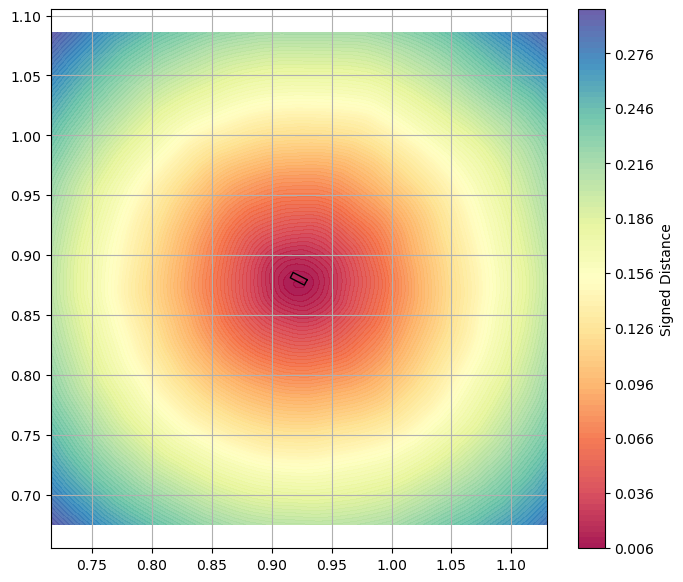

Epoch 1/5, Loss: 893.7591369194492, TEST Loss: 0.1803961843252182
0.027424084022641182


100%|██████████| 281/281 [00:16<00:00, 17.25it/s]


Epoch 1/30, Train Loss: 0.0885285136, Validation Loss: 0.0120907302, Testing Loss: 0.0124579690
Epoch 11/30, Train Loss: 0.0080375470, Validation Loss: 0.0089393715, Testing Loss: 0.0090882228
Epoch 21/30, Train Loss: 0.0071518923, Validation Loss: 0.0083539166, Testing Loss: 0.0083572282
Epoch 30/30, Train Loss: 0.0094171518, Validation Loss: 0.0071403532, Testing Loss: 0.0071555338
Average Testing Loss over 1 trainings: 0.0071555338, Std: 0.0000000000


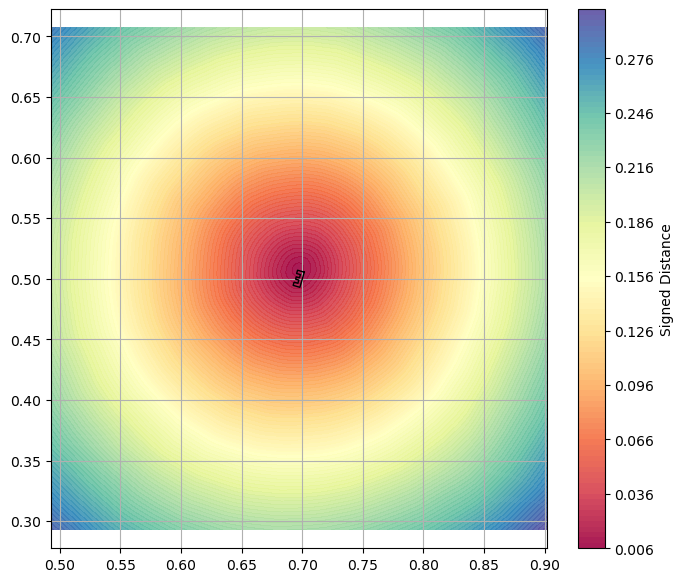

Epoch 2/5, Loss: 180.9932545020487, TEST Loss: 0.13466361444443464
0.029664281755685806


100%|██████████| 281/281 [00:16<00:00, 17.44it/s]


Epoch 1/30, Train Loss: 0.0981006904, Validation Loss: 0.0142782865, Testing Loss: 0.0143444262
Epoch 11/30, Train Loss: 0.0067918972, Validation Loss: 0.0074280566, Testing Loss: 0.0074996829
Epoch 21/30, Train Loss: 0.0065400436, Validation Loss: 0.0070179973, Testing Loss: 0.0069166151
Epoch 30/30, Train Loss: 0.0060833216, Validation Loss: 0.0062110430, Testing Loss: 0.0062342437
Average Testing Loss over 1 trainings: 0.0062342437, Std: 0.0000000000


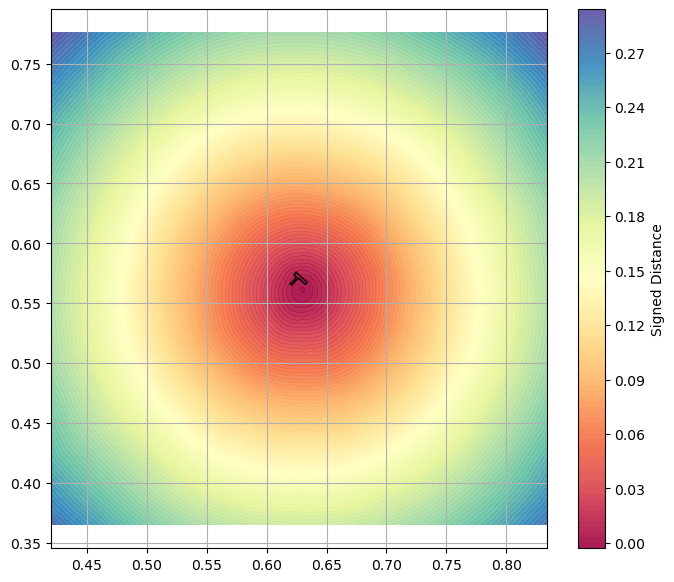

Epoch 3/5, Loss: 155.10069011538903, TEST Loss: 0.07005556020885706
0.03159722313284874


100%|██████████| 281/281 [00:16<00:00, 17.26it/s]


Epoch 4/5, Loss: 133.87677601987357, TEST Loss: 0.1828001756221056
0.033246636390686035


100%|██████████| 281/281 [00:16<00:00, 17.30it/s]


Epoch 5/5, Loss: 136.16377395412675, TEST Loss: 0.09769591828808188


In [63]:
model = Geo2Vec_Model(n_poly=max_id + 2, z_size=z_size, hidden_size=hidden_size, num_freqs=num_freqs,
                        weight_decay=weight_decay, log_sampling=log_sampling,
                        polar_fourier=polar_fourier, num_layers=num_layers).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = SDFLoss(code_reg_weight=code_reg_weight, sum=True)
id_range = torch.arange(0, max_id + 2, dtype=torch.long).to(device)
best_val_loss = float('inf')
for epoch in range(epochs):
    print(torch.std(model.poly_embedding_layer.weight).item())
    model.train()
    epoch_loss = 0
    for id, sample, dist in tqdm(dataloader):
        id = id.to(device)
        sample = sample.to(device)
        dist = dist.to(device)
        optimizer.zero_grad()
        output = model(id, sample)
        latend_code = model.poly_embedding_layer(id_range)
        loss = loss_fn(output, dist, latend_code)  # , latend_code
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    test_epoch_loss = 0
    with torch.no_grad():
        model.eval()
        for id, sample, dist in val_dataloader:
            id = id.to(device)
            sample = sample.to(device)
            dist = dist.to(device)
            output = model(id, sample)
            loss = F.l1_loss(output, dist, reduction='mean')
            test_epoch_loss += loss.item()

    if best_val_loss > test_epoch_loss:
        #torch.save(model.state_dict(), save_file_name)
        location_embedding = model.poly_embedding_layer.weight.data[:len(polys_dict_loc)].cpu().numpy()
        #np.save(save_file_name.replace('.pth', '_loc'), location_embedding)
        best_val_loss = test_epoch_loss

        if args.test_representation_location:
            test_representation.test_distance(polys_dict_loc, location_embedding, num_training=1, num_epochs=30,
                                                type1 = 'Polygon', type2 = 'Polygon',
                                                num_pairs=50000)
        if args.visualSDF_location:
            visualization.random_visualization(polys_dict_loc, model)

    print(f'Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss / len(dataloader)}, TEST Loss: {test_epoch_loss}')


In [ ]:
# Save the location embedding to wherever you want
# save_file_name = 'location.npy'
# np.save(save_file_name, location_embedding[:len(poly_ids)])